# HDBSCAN Clustering Pipeline — Emergency Department Care Utilization

**Author:** Nadia ELORGA-CASTAGNET  
**Supervisors:** Pr. Cédric Gil-Jardiné (AHeaD) & Dr. Marta Avalos-Fernandez (SISTM)  
**CHU de Bordeaux — Master 2 PHDS 2025/2026**

---

## Pipeline overview

```
CHUNK 1 — Configuration, imports, column definitions
CHUNK 2 — All functions (distance matrix, HDBSCAN, sweeps, visualizations)
CHUNK 3 — STEP 1: Distance matrix + mcs sweep → choose optimal mcs
CHUNK 4 — STEP 2: min_samples sweep → choose optimal min_samples  
CHUNK 5 — STEP 3: Final run with full visualizations
```

### Key methodological choices
- **Scenario 2** (binary flags + counts): Hamming + Manhattan distance (GPU). Quantitative variables standardized with **MinMax or StandardScaler** — both are tested and compared.
- **Scenario 3** (Gower → UMAP → HDBSCAN): Gower distance handles mixed variables natively, normalizing quantitative variables by range (equivalent to implicit MinMax). **No scaler comparison needed for Scenario 3.**
- **min_samples sweep**: Run AFTER choosing the optimal mcs, as recommended by scikit-learn documentation.

---
## CHUNK 1 — Configuration, Imports & Column Definitions


In [19]:
# ==============================================================================
# 0. CONFIGURATION — Edit only this block
# ==============================================================================

# ── Paths ──────────────────────────────────────────────────────────────────────
CSV_PATH   = "df_final_binaire_imputed.csv"
OUTPUT_DIR = "Results/Regular_clustering/Split_dataset"

# ── GPU ────────────────────────────────────────────────────────────────────────
GPU_DEVICE_ID = 1

# ── Scalers to compare (Scenario 2 ONLY — Scenario 3 uses Gower which normalizes internally) ──
# Gower distance normalizes quantitative variables by range (implicit MinMax).
# Therefore, scaler comparison only makes sense for Scenario 2.
SCALERS = "minmax"  # both will be tested for Scenario 2 only

# ── UMAP — dimensionality reduction before HDBSCAN (Scenario 3 only) ──────────
UMAP_N_NEIGHBORS  = 30   # number of neighbors for manifold learning
UMAP_MIN_DIST     = 0.0  # 0.0 = tightly packed clusters → better for HDBSCAN
UMAP_N_COMPONENTS = 10   # output dimensions
UMAP_RANDOM_STATE = 42

# ── UMAP / t-SNE — visualization only (2D/3D projections) ────────────────────
VIZ_N_NEIGHBORS = 30
VIZ_MIN_DIST    = 0.1   # slightly more spread for readability
VIZ_TSNE_PERP   = 30
VIZ_TSNE_ITER   = 1500

# ── HDBSCAN — fixed run parameters (updated after sweep) ──────────────────────
# These are the DEFAULT values used for the initial fixed run.
# Update BEST_MCS and BEST_MS after running the sweeps (Chunks 3 & 4).
HDBSCAN_MIN_CLUSTER_SIZE = 1000       # will be overridden by sweep results
HDBSCAN_MIN_SAMPLES      = 10  # = mcs (sklearn default recommendation)
HDBSCAN_CLUSTER_METHOD   = "eom"      # Excess of Mass: selects most stable clusters

# ── STEP 1: mcs sweep configuration ──────────────────────────────────────────
# Sweeps min_cluster_size while keeping min_samples = mcs at each iteration
# (sklearn recommendation: tune mcs first with default min_samples)
SWEEP_MCS_VALUES  = list(range(200, 2500, 100))              # range to explore
SWEEP_MIN_SAMPLES = {mcs: mcs for mcs in SWEEP_MCS_VALUES}  # min_samples = mcs dynamically

# ── STEP 2: min_samples sweep configuration ───────────────────────────────────
# Fill in BEST_MCS after analyzing the mcs sweep results in Chunk 3.
# Then run Chunk 4 to sweep min_samples.
#
# ! UPDATE THESE VALUES AFTER CHUNK 3 !
# ⚠️ UPDATE AFTER SWEEP ⚠️
BEST_MCS = {
    "hospitalized_s2"       : 1000,
    "discharged_s2"         : 1000,
    "hospitalized_s3"       : 1000,
    "discharged_s3"         : 1000,
}

# min_samples sweep range: starts at 1 (reference), fine-grained up to 100,
# then coarser up to best_mcs. Will be computed dynamically per run.
def make_ms_sweep(best_mcs: int) -> list:
    """Build the min_samples sweep range for a given best_mcs.
    Starts at 1 (no density constraint), fine-grained up to 100,
    then coarser steps up to best_mcs.
    """
    return [1] + list(range(10, 100, 20)) + list(range(100, best_mcs + 1, 50))

# ── STEP 3: Final run parameters ──────────────────────────────────────────────
# Fill in after analyzing both sweeps (Chunks 3 & 4).
#
# ! UPDATE THESE VALUES AFTER CHUNKS 3 & 4 !
FINAL_PARAMS = {
    # format: run_key → (min_cluster_size, min_samples)
    "hospitalized_s2"       : (1000, 100),
    "discharged_s2"         : (1000, 100),
    "hospitalized_s3"       : (1000, 100),
    "discharged_s3"         : (1000, 100),
}

# ── Combined score weights (used in mcs sweep to select best mcs) ─────────────
# Score = w_sil * silhouette_norm + w_stab * stability_norm - w_out * outlier_rate
# Higher silhouette → better separated clusters
# Higher stability → more robust clusters (HDBSCAN condensed tree)
# Lower outlier rate → fewer patients labeled as noise
W_SILHOUETTE = 0.4
W_STABILITY  = 0.3
W_OUTLIER    = 0.3

# ── Scenario 2 weights ────────────────────────────────────────────────────────
WEIGHT_HOSP_S2 = 3.0   # hospitalization × 3 in the distance matrix

# ── Scenario 3 weights (Gower) ────────────────────────────────────────────────
# Technical down-weighting: each group of detailed variables counts as ~1 variable total
# instead of dominating the distance by sheer number.
# 29 venous biology vars × (1/29) = 1.0 total weight
# 12 detailed imaging vars × (1/12) = 1.0 total weight
WEIGHT_BIO_VEINOUS      = 1 / 29
WEIGHT_IMAGING_DETAILED = 1 / 12
WEIGHT_HOSP_S3          = 5.0   # hospitalization × 5 for confirmatory run

# ── Binning for count variables (used in descriptive analysis) ────────────────
BIO_BINS    = [-1, 0, 1, 2, 10]
BIO_LABELS  = ["0", "1", "2", "3+"]
IMAG_BINS   = [-1, 0, 1, 2, 10]
IMAG_LABELS = ["0", "1", "2", "3+"]


# ==============================================================================
# 1. IMPORTS
# ==============================================================================

import os
import logging
import time
import gower
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import umap
import umap.umap_ as umap_reduce
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, silhouette_score

log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# ── GPU setup ──────────────────────────────────────────────────────────────────
torch.cuda.set_device(GPU_DEVICE_ID)
torch.cuda.set_per_process_memory_fraction(0.5, device=GPU_DEVICE_ID)
print(f"GPU : {torch.cuda.get_device_name(GPU_DEVICE_ID)}")
print(f"Available memory : {torch.cuda.get_device_properties(GPU_DEVICE_ID).total_memory / 1e9:.0f} GB")


# ==============================================================================
# 2. COLUMN DEFINITIONS
# ==============================================================================

# ── Imaging modality flags (binary) ───────────────────────────────────────────
IMAGING_COLS_BOOL = {
    "has_ultrasound", "has_ct_scan", "has_xray", "has_mri",
}

# ── Imaging anatomical detail (binary) — Scenario 3 only ──────────────────────
IMAGING_COLS_DETAILED = {
    "ultrasound_1", "ultrasound_2",
    "ct_scan_1", "ct_scan_2", "ct_scan_3",
    "xray_1", "xray_2", "xray_3",
    "mri_1", "mri_2",
}

# ── Venous biology panel (binary flags) — Scenario 3 only ─────────────────────
BIO_VEINOUS = {
    "is_hemoglobine", "is_leucocytes", "is_formule_leuco",
    "is_urea", "is_creatinine", "is_sodium", "is_potassium",
    "is_platelets", "is_pt", "is_aptt", "is_calcium", "is_ck",
    "is_lactates", "is_troponine", "is_bnp", "is_ckmb", "is_ddimer",
    "is_crp", "is_pct", "is_alat", "is_asat", "is_bili_total",
    "is_lipase", "is_alp", "is_iron", "is_ferritin",
    "is_calcium_ionized", "is_aXa_aIIa", "is_fibrinogen",
}

# ── Laboratory workup flags (binary) ──────────────────────────────────────────
BIO_EXAMS = {
    "has_blood_test", "has_culture",
    "has_lumbar_puncture", "has_blood_gas",
}

# ── Procedures & patient disposition (binary) ─────────────────────────────────
PROCEDURE_COLS   = {"had_ekg"}
DISPOSITION_COLS = {
    "hospitalization", "observation_unit", "inter_facility_transfer",
}

# ── Quantitative variables ─────────────────────────────────────────────────────
# These are the ONLY variables that need standardization in Scenario 2.
# In Scenario 3, Gower handles them automatically.
COLS_QUANTI = ["imaging_exam_count", "bio_exam_count"]



# ── Scenario definitions ──────────────────────────────────────────────────────
# Scenario 2: modality-level binary flags + exam counts
#   → Hamming (binary) + Manhattan (quantitative) distance on GPU
#   → Scaler comparison: MinMax vs StandardScaler
#
# Scenario 3: full detail (modality + anatomical + venous biology + counts)
#   → Gower distance (handles mixed types natively)
#   → UMAP dimensionality reduction before HDBSCAN
#   → No scaler comparison needed (Gower normalizes internally with min max)

SCENARIOS = {
    "scenario_2": list(
        IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS
    ) + COLS_QUANTI,

    "scenario_3": list(
        IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS
        | IMAGING_COLS_DETAILED | BIO_VEINOUS
    ) + COLS_QUANTI,
}

print(f"Scenario 2: {len(SCENARIOS['scenario_2'])} variables")
print(f"Scenario 3: {len(SCENARIOS['scenario_3'])} variables")

GPU : NVIDIA A100-SXM4-80GB
Available memory : 85 GB
Scenario 2: 14 variables
Scenario 3: 53 variables


---
## CHUNK 2 — All Functions


In [20]:
# ==============================================================================
# FUNCTION 1: Data loading and preprocessing
# ==============================================================================

def load_and_preprocess(csv_path: str = CSV_PATH) -> pd.DataFrame:
    """Load the raw CSV and add ordinal binned columns for count variables."""
    df = pd.read_csv(csv_path, low_memory=False)

    # Create categorical bins for count variables (used in descriptive analysis)
    df["bio_exam_cat"] = pd.cut(df["bio_exam_count"], bins=BIO_BINS, labels=BIO_LABELS)
    df["imaging_exam_cat"] = pd.cut(df["imaging_exam_count"], bins=IMAG_BINS, labels=IMAG_LABELS)

    for col in ("bio_exam_count", "imaging_exam_count"):
        dist = (
            df[col].value_counts(dropna=False).sort_index()
            .rename_axis(col).reset_index(name="n")
        )
        dist["pct"] = (dist["n"] / dist["n"].sum() * 100).round(1)
        log.info(f"\n{col} distribution:\n{dist.to_string(index=False)}")

    return df


# ==============================================================================
# FUNCTION 2: Distance matrix computation — GPU (Scenario 2)
# ==============================================================================

def compute_distance_matrix_gpu(
    df_sub:        pd.DataFrame,
    binary_cols:   list,
    cat_cols:      list,
    quanti_cols:   list,
    weight_hosp:   float = 1.0,
    weight_quanti: float = 1.0,
    scaler:        str   = "minmax",   # "minmax" or "standard"
    device_id:     int   = GPU_DEVICE_ID,
) -> np.ndarray:
    """
    Compute pairwise distance matrix on GPU (PyTorch).

    Distance logic:
    - Binary variables → Hamming distance (L1 on 0/1 values)
      Hamming chosen over Jaccard because double-zeros (both patients
      didn't have an exam) are clinically meaningful and should count
      as similarity — Jaccard ignores them.
    - Quantitative variables → Manhattan distance (L1) after scaling.
      Manhattan chosen over Euclidean for robustness to outliers.
    - Scaler: MinMax rescales to [0,1] (consistent with binary range);
      StandardScaler centers and reduces (mean=0, std=1).

    Returns float64 numpy array of shape (n, n).
    """
    device = torch.device(f"cuda:{device_id}")
    n      = len(df_sub)
    D      = torch.zeros((n, n), device=device, dtype=torch.float32)

    # Binary variables: Hamming distance (L1 on 0/1)
    for col in binary_cols:
        vals = torch.tensor(df_sub[col].values, dtype=torch.float32, device=device).unsqueeze(1)
        d = torch.cdist(vals, vals, p=1)
        w = weight_hosp if col == "hospitalization" else 1.0  # optional over-weighting
        D += d * w

    # Categorical variables: Hamming (0 if equal, 1 if different)
    for col in cat_cols:
        codes = torch.tensor(df_sub[col].cat.codes.values, dtype=torch.float32, device=device).unsqueeze(1)
        D += (codes != codes.T).float()

    # Quantitative variables: Manhattan after scaling
    if quanti_cols:
        q = df_sub[quanti_cols].values.astype("float32")
        if scaler == "minmax":
            # MinMax: rescales to [0,1] — consistent with binary variable range
            q_scaled = MinMaxScaler().fit_transform(q).astype("float32")
        else:
            # Standard: mean=0, std=1 — more robust to extreme values
            q_scaled = StandardScaler().fit_transform(q).astype("float32")
        q_tensor = torch.tensor(q_scaled, dtype=torch.float32, device=device)
        D += torch.cdist(q_tensor, q_tensor, p=1) * weight_quanti

    D.fill_diagonal_(0)
    return D.cpu().numpy().astype(np.float64)


# ==============================================================================
# FUNCTION 3: Main HDBSCAN run
# ==============================================================================

def run_hdbscan(
    df:               pd.DataFrame,
    scenario_name:    str,
    run_label:        str,
    distance_metric:  str,            # "precomputed" (Scenario 2) or "gower" (Scenario 3)
    scaler:           str   = "minmax",  # Scenario 2 only; ignored for Scenario 3
    weight_hosp:      float = 1.0,
    weight_quanti:    float = 1.0,
    gower_weights:    dict  = None,   # per-column weights for Gower
    min_cluster_size: int   = HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples:      int   = HDBSCAN_MIN_SAMPLES,
) -> tuple:
    """
    Full HDBSCAN clustering run.

    Steps:
    1. Select and clean columns for the scenario
    2. Detect variable types (binary, categorical, quantitative)
    3. Compute distance matrix (Hamming+Manhattan GPU or Gower)
    4. For Scenario 3: UMAP dimensionality reduction on Gower matrix
    5. HDBSCAN clustering
    6. Export labeled CSV

    Returns: (df_sub, D, fit_input, labels, clusterer)
    - df_sub: subset dataframe used for clustering
    - D: raw distance matrix (always returned for visualization)
    - fit_input: what HDBSCAN was fitted on (= D for Scenario 2, UMAP embedding for Scenario 3)
    - labels: cluster assignments (-1 = outlier/noise)
    - clusterer: fitted HDBSCAN object (gives access to condensed tree, etc.)
    """
    # Output directory includes scaler name for Scenario 2 (for comparison)
    # Scenario 3 has no scaler comparison, so no scaler subdirectory
    if distance_metric == "precomputed":
        sc_dir = os.path.join(OUTPUT_DIR, scaler, run_label)
    else:
        sc_dir = os.path.join(OUTPUT_DIR, "gower", run_label)
    os.makedirs(sc_dir, exist_ok=True)

    # ── Column selection ───────────────────────────────────────────────────────
    cols   = [c for c in SCENARIOS[scenario_name] if c in df.columns]
    df_sub = df[cols].copy()

    # Scenario 3: keep NaN in detailed columns (Gower handles them)
    if scenario_name == "scenario_3":
        essential = [c for c in cols if c not in IMAGING_COLS_DETAILED and c not in BIO_VEINOUS]
        df_sub    = df_sub.dropna(subset=essential)
    else:
        df_sub = df_sub.dropna()

    idx = df_sub.index

    # ── Automatic type detection ───────────────────────────────────────────────
    quanti_cols = [c for c in COLS_QUANTI if c in df_sub.columns]
    binary_cols = [
        c for c in df_sub.columns
        if c not in quanti_cols and set(df_sub[c].dropna().unique()) <= {0, 1}
    ]
    cat_cols = [
        c for c in df_sub.columns
        if c not in binary_cols and c not in quanti_cols
    ]
    for col in cat_cols:
        df_sub[col] = df_sub[col].astype("category")

    log.info(
        f"[{run_label}] binary={len(binary_cols)} | "
        f"cat={len(cat_cols)} | quanti={len(quanti_cols)} | n={len(df_sub)}"
    )

    # ── Distance matrix ────────────────────────────────────────────────────────
    t0       = time.time()
    col_list = list(df_sub.columns)
    n_vars   = len(col_list)

    if distance_metric == "gower":
        # Gower requires float64 (not int) and object (not CategoricalDtype)
        df_gower = df_sub.copy()
        for col in df_gower.select_dtypes(include="integer").columns:
            df_gower[col] = df_gower[col].astype("float64")
        for col in df_gower.select_dtypes(include="category").columns:
            df_gower[col] = df_gower[col].astype("object")

        # Per-column weights (default = 1.0 = neutral)
        weights = np.ones(n_vars)
        if gower_weights:
            for col, w in gower_weights.items():
                if col in col_list:
                    weights[col_list.index(col)] = w
        weights = weights / weights.sum() * n_vars  # normalize so sum = n_vars

        D = gower.gower_matrix(df_gower, weight=weights)
        D = D.astype(np.float64)
        np.fill_diagonal(D, 0)
        fit_input      = D
        hdbscan_metric = "precomputed"

    elif distance_metric == "precomputed":
        D = compute_distance_matrix_gpu(
            df_sub,
            binary_cols   = binary_cols,
            cat_cols      = cat_cols,
            quanti_cols   = quanti_cols,
            weight_hosp   = weight_hosp,
            weight_quanti = weight_quanti,
            scaler        = scaler,
        )
        fit_input      = D
        hdbscan_metric = "precomputed"
    else:
        raise ValueError(f"distance_metric must be 'gower' or 'precomputed', got '{distance_metric}'.")

    log.info(f"[{run_label}] Distance matrix: {time.time()-t0:.1f}s")

    # ── UMAP reduction (Scenario 3 only) ──────────────────────────────────────
    # UMAP is applied on the Gower distance matrix to reduce dimensionality
    # before HDBSCAN. This avoids the curse of dimensionality.
    # HDBSCAN then runs on the UMAP embedding with Euclidean distance.
    if scenario_name == "scenario_3":
        t0 = time.time()
        reducer = umap_reduce.UMAP(
            n_neighbors  = UMAP_N_NEIGHBORS,
            min_dist     = UMAP_MIN_DIST,
            n_components = UMAP_N_COMPONENTS,
            metric       = "precomputed",
            random_state = UMAP_RANDOM_STATE,
        )
        emb = reducer.fit_transform(D)
        np.save(os.path.join(sc_dir, "umap_embedding.npy"), emb)
        log.info(f"[{run_label}] UMAP embedding shape={emb.shape} — {time.time()-t0:.1f}s")
        fit_input      = emb           # HDBSCAN and sweeps run on UMAP embedding
        hdbscan_metric = "euclidean"   # Euclidean on UMAP coordinates

    # ── HDBSCAN clustering ────────────────────────────────────────────────────
    t0 = time.time()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size         = min_cluster_size,
        min_samples              = min_samples,
        metric                   = hdbscan_metric,
        cluster_selection_method = HDBSCAN_CLUSTER_METHOD,
        gen_min_span_tree        = True,  # required for condensed tree & MST visualizations
    ).fit(fit_input)
    log.info(f"[{run_label}] HDBSCAN: {time.time()-t0:.1f}s")

    labels     = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    log.info(f"[{run_label}] clusters={n_clusters} | noise={n_noise} ({100*n_noise/len(labels):.1f}%)")

    # Export labeled dataset
    df_out = df.loc[idx].copy()
    df_out["cluster"] = labels
    df_out.to_csv(os.path.join(sc_dir, f"clustering_mcs{min_cluster_size}.csv"), index=False)

    return df_sub, D, fit_input, labels, clusterer


# ==============================================================================
# FUNCTION 4: mcs sweep
# ==============================================================================

def run_hdbscan_sweep(
    fit_input:    np.ndarray,
    metric:       str,
    sweep_values: list = SWEEP_MCS_VALUES,
) -> pd.DataFrame:
    """
    Sweep over min_cluster_size values.

    At each iteration, min_samples = min_cluster_size (sklearn default recommendation).
    This ensures a coherent density definition relative to the cluster size.

    Metrics collected:
    - Silhouette score: cluster compactness and separation
      (note: systematically lower for density-based algorithms than k-means)
    - Stability (cluster persistence): how long each cluster survives in the
      condensed tree — the most appropriate metric for HDBSCAN
    - Outlier rate: proportion of patients labeled as noise (-1)
    """
    if metric == "precomputed":
        np.fill_diagonal(fit_input, 0)
    results = []

    for mcs in sweep_values:
        ms = SWEEP_MIN_SAMPLES[mcs]  # dynamic: min_samples = mcs

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size         = mcs,
            min_samples              = ms,
            metric                   = metric,
            cluster_selection_method = HDBSCAN_CLUSTER_METHOD,
            gen_min_span_tree        = True,
        ).fit(fit_input)

        labels          = clusterer.labels_
        unique_clusters = np.unique(labels[labels >= 0])
        n_clusters      = len(unique_clusters)

        sil = (
            silhouette_score(fit_input, labels, metric=metric)
            if n_clusters >= 2 else np.nan
        )
        stability = (
            float(np.mean(clusterer.cluster_persistence_))
            if len(clusterer.cluster_persistence_) > 0 else np.nan
        )

        results.append({
            "min_cluster_size": mcs,
            "min_samples":      ms,
            "n_clusters":       n_clusters,
            "silhouette":       sil,
            "outlier_rate":     float(np.mean(labels == -1)),
            "stability":        stability,
            "labels":           labels,
            "probabilities":    clusterer.probabilities_,
            "cluster_sizes":    {c: int(np.sum(labels == c)) for c in unique_clusters},
            "clusterer":        clusterer,
        })

        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "nan"
        log.info(
            f"mcs={mcs:5d} | clusters={n_clusters} | "
            f"outlier={np.mean(labels==-1)*100:.1f}% | sil={sil_str}"
        )

    return pd.DataFrame(results)


def compute_combined_score(
    df_sweep: pd.DataFrame,
    w_sil:    float = W_SILHOUETTE,
    w_stab:   float = W_STABILITY,
    w_out:    float = W_OUTLIER,
) -> pd.DataFrame:
    """
    Add a combined quality score to the sweep results.

    Score = w_sil * silhouette_norm + w_stab * stability_norm - w_out * outlier_rate

    Silhouette and stability are min-max normalized before combining.
    Outlier rate is subtracted directly (already in [0,1]).
    """
    df = df_sweep.copy()
    df["silhouette"] = df["silhouette"].fillna(0)
    df["stability"]  = df["stability"].fillna(0)

    def _minmax(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn) if mx != mn else s * 0

    df["combined_score"] = (
        w_sil * _minmax(df["silhouette"])
        + w_stab * _minmax(df["stability"])
        - w_out * df["outlier_rate"]
    )
    return df


# ==============================================================================
# FUNCTION 5: min_samples sweep
# ==============================================================================

def run_min_samples_sweep(
    fit_input:    np.ndarray,
    metric:       str,
    best_mcs:     int,
    run_label:    str,
    out_dir:      str,
    sweep_ms:     list = None,   # if None, computed from best_mcs
) -> pd.DataFrame:
    """
    Sweep min_samples with a fixed min_cluster_size (best_mcs from Step 1).

    Sweep range:
    - Starts at 1: no density constraint (reference extreme)
    - Fine-grained from 10 to 100 (captures the low-ms behavior)
    - Coarser steps up to best_mcs

    Effects of min_samples:
    - Large min_samples → stricter density → more outliers → more compact clusters
    - Small min_samples → looser density → fewer outliers → more inclusive clusters
    """
    if sweep_ms is None:
        sweep_ms = make_ms_sweep(best_mcs)

    if metric == "precomputed":
        np.fill_diagonal(fit_input, 0)
    results = []

    for ms in sweep_ms:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size         = best_mcs,
            min_samples              = ms,
            metric                   = metric,
            cluster_selection_method = HDBSCAN_CLUSTER_METHOD,
            gen_min_span_tree        = True,
        ).fit(fit_input)

        labels          = clusterer.labels_
        unique_clusters = np.unique(labels[labels >= 0])
        n_clusters      = len(unique_clusters)

        sil = (
            silhouette_score(fit_input, labels, metric=metric)
            if n_clusters >= 2 else np.nan
        )
        stability = (
            float(np.mean(clusterer.cluster_persistence_))
            if len(clusterer.cluster_persistence_) > 0 else np.nan
        )

        results.append({
            "min_samples":      ms,
            "min_cluster_size": best_mcs,
            "n_clusters":       n_clusters,
            "silhouette":       sil,
            "outlier_rate":     float(np.mean(labels == -1)),
            "stability":        stability,
            "labels":           labels,
            "clusterer":        clusterer,
        })

        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "nan"
        log.info(
            f"[{run_label}] ms={ms:5d} | clusters={n_clusters} | "
            f"bruit={np.mean(labels==-1)*100:.1f}% | sil={sil_str}"
        )


    df_results = pd.DataFrame(results)

    # Save results
    os.makedirs(out_dir, exist_ok=True)
    df_results.drop(columns=["labels", "clusterer"]).to_csv(
        os.path.join(out_dir, f"ms_sweep_mcs{best_mcs}.csv"), index=False
    )

    # Plot sweep curves
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    axes[0].plot(df_results["min_samples"], df_results["n_clusters"], marker="o", color="tab:blue")
    axes[0].set_ylabel("Number of clusters")
    axes[0].set_title(f"min_samples sweep — {run_label} (mcs={best_mcs})")
    axes[0].grid(True)
    axes[1].plot(df_results["min_samples"], df_results["outlier_rate"] * 100, marker="s", color="tab:red")
    axes[1].set_ylabel("Outlier rate (%)")
    axes[1].grid(True)
    axes[2].plot(df_results["min_samples"], df_results["silhouette"], marker="d", color="tab:green")
    axes[2].set_ylabel("Silhouette score")
    axes[2].set_xlabel("min_samples")
    axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "min_samples_sweep.png"), dpi=150)
    plt.show()

    log.info(f"[{run_label}] min_samples sweep done → {out_dir}")
    return df_results


# ==============================================================================
# FUNCTION 6: Sweep curves visualization
# ==============================================================================

def plot_sweep_curves(df_sweep, title, out_dir, filename_prefix):
    """Plot silhouette/stability and combined score curves from the mcs sweep."""
    os.makedirs(out_dir, exist_ok=True)
    x = df_sweep["min_cluster_size"]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(x, df_sweep["silhouette"], color="tab:blue", marker="o", label="Silhouette")
    ax1.set_xlabel("min_cluster_size")
    ax1.set_ylabel("Silhouette score", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(x, df_sweep["stability"], color="tab:red", marker="s", label="Stability")
    ax2.set_ylabel("Mean stability", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    plt.title(title)
    fig.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{filename_prefix}_silhouette_stability.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(x, df_sweep["combined_score"], color="tab:green", marker="d", linewidth=2)
    plt.xlabel("min_cluster_size")
    plt.ylabel("Combined score")
    plt.title(f"Combined score — {title}")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, f"{filename_prefix}_combined_score.png"), dpi=150)
    plt.show()


# ==============================================================================
# FUNCTION 7: HDBSCAN native tree visualizations
# ==============================================================================

def plot_hdbscan_trees(clusterer, run_label, out_dir):
    """
    Generate HDBSCAN native visualizations:

    1. Condensed Tree: pruned hierarchy showing cluster stability (lambda = 1/distance).
       Replaces the set of individual dendrograms per mcs — one figure shows everything.
       Higher = more stable cluster. Wider = more patients.

    2. Single Linkage Tree: complete raw hierarchy before pruning.
       Shows all merge steps. X-axis has no clinical meaning — it's merge order.
       Useful for debugging data structure.

    3. Minimum Spanning Tree: connectivity graph.
       Only available when metric != 'precomputed' (i.e., Scenario 3 with UMAP Euclidean).

    4. Cluster Persistence: bar chart of stability per cluster.
       Highest bar = most robust cluster regardless of mcs choice.
    """
    os.makedirs(out_dir, exist_ok=True)

    # 1. Condensed Tree
    try:
        fig, ax = plt.subplots(figsize=(14, 7))
        clusterer.condensed_tree_.plot(select_clusters=True, axis=ax, colorbar=True)
        ax.set_title(f"Condensed Tree — {run_label}\n(Y = λ = 1/distance | higher = more stable)", fontsize=11)
        ax.set_xlabel("Points / clusters")
        ax.set_ylabel("λ (stability)")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "condensed_tree.png"), dpi=150)
        plt.show()
        log.info(f"[{run_label}] condensed_tree.png saved")
    except Exception as e:
        log.warning(f"[{run_label}] Condensed tree: {e}")

    # 2. Single Linkage Tree
    try:
        fig, ax = plt.subplots(figsize=(14, 7))
        clusterer.single_linkage_tree_.plot(axis=ax)
        ax.set_title(f"Single Linkage Tree — {run_label}\n(complete raw hierarchy before pruning)", fontsize=11)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "single_linkage_tree.png"), dpi=150)
        plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] Single linkage tree: {e}")

    # 3. Minimum Spanning Tree (Scenario 3 only — not available with precomputed metric)
    try:
        mst = clusterer.minimum_spanning_tree_
        if mst is None:
            log.info(f"[{run_label}] MST not available with metric='precomputed' (Scenario 2)")
        else:
            fig, ax = plt.subplots(figsize=(14, 7))
            mst.plot(edge_cmap="viridis", edge_alpha=0.6, node_size=10, axis=ax)
            ax.set_title(f"Minimum Spanning Tree — {run_label}", fontsize=11)
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, "minimum_spanning_tree.png"), dpi=150)
            plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] MST: {e}")

    # 4. Cluster Persistence
    try:
        persistence = clusterer.cluster_persistence_
        if len(persistence) > 0:
            fig, ax = plt.subplots(figsize=(max(6, len(persistence)), 4))
            colors = ["#e05c2e" if p == max(persistence) else "#aec6cf" for p in persistence]
            ax.bar(range(len(persistence)), persistence, color=colors)
            ax.set_xlabel("Cluster ID")
            ax.set_ylabel("Persistence (stability)")
            ax.set_title(f"Cluster Persistence — {run_label}\n(red = most stable cluster)")
            ax.set_xticks(range(len(persistence)))
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, "cluster_persistence.png"), dpi=150)
            plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] Cluster persistence: {e}")


# ==============================================================================
# FUNCTION 8: Cluster profile heatmap
# ==============================================================================

def plot_cluster_heatmap(df_sub, labels, title, out_dir, filename):
    """
    Heatmap of mean variable values per cluster.
    Allows clinical interpretation of each cluster's resource utilization profile.
    Outliers (-1) are excluded from the profile computation.
    """
    os.makedirs(out_dir, exist_ok=True)
    df_prof            = df_sub.copy()
    df_prof["cluster"] = labels
    df_prof            = df_prof[df_prof["cluster"] != -1]

    if df_prof.empty:
        log.warning(f"[{title}] No clusters found — heatmap skipped.")
        return pd.DataFrame()

    numeric_cols = [
        c for c in df_prof.select_dtypes(include=["number"]).columns.tolist()
        if c != "cluster"
    ]
    profile = df_prof[numeric_cols + ["cluster"]].groupby("cluster").mean().round(3)

    if profile.empty or profile.shape[0] == 0 or profile.shape[1] == 0:
        log.warning(f"[{title}] Empty profile — heatmap skipped.")
        return profile

    n_cols = profile.shape[1]
    n_rows = profile.shape[0]
    plt.figure(figsize=(max(8, n_cols * 0.8), max(4, n_rows * 0.6)))
    sns.heatmap(profile, annot=True, cmap="YlOrRd", fmt=".2f",
                annot_kws={"size": max(6, min(10, 80 // n_cols))})
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    path = os.path.join(out_dir, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info(f"Saved: {path}")
    return profile


def plot_cluster_dendrogram(profile, title, out_dir, filename):
    """
    Ward dendrogram on cluster profiles.
    Shows how clusters relate to each other based on their mean variable profiles.
    Different from the HDBSCAN condensed tree: this one groups the FINAL clusters,
    not the individual data points.
    """
    os.makedirs(out_dir, exist_ok=True)
    Z               = linkage(profile.values, method="ward")
    variables       = profile.columns.tolist()
    cluster_vectors = {i: profile.iloc[i].values for i in range(len(profile))}

    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=profile.index.astype(str))
    plt.gca().grid(False)
    plt.title(title)

    # Annotate each merge with the most discriminating variable
    for i, (c1, c2, dist, _) in enumerate(Z):
        c1, c2  = int(c1), int(c2)
        v1, v2  = cluster_vectors[c1], cluster_vectors[c2]
        top_var = variables[np.argmax(np.abs(v1 - v2))]
        cluster_vectors[len(cluster_vectors)] = (v1 + v2) / 2
        plt.text(i + 1, dist, top_var, rotation=45, fontsize=8, va="bottom", ha="center")

    plt.tight_layout()
    path = os.path.join(out_dir, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    log.info(f"Saved: {path}")


# ==============================================================================
# FUNCTION 9: UMAP & t-SNE visualizations
# ==============================================================================

def build_cluster_palette(labels):
    """Build a consistent color map: clusters → distinct colors, outliers → grey."""
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    n_clusters      = len(unique_clusters)
    palette         = sns.color_palette("tab20", n_clusters) if n_clusters <= 20 \
                      else sns.color_palette("hsv", n_clusters)
    color_map       = {c: palette[i] for i, c in enumerate(unique_clusters)}
    color_map[-1]   = "lightgrey"
    return color_map


def _scatter_clusters(emb, labels, color_map, title, out_dir, filename):
    """Internal helper: 2D scatter plot colored by cluster."""
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    plt.figure(figsize=(9, 7))
    mask_noise = labels == -1
    if mask_noise.any():
        plt.scatter(emb[mask_noise, 0], emb[mask_noise, 1],
                    c="lightgrey", s=8, linewidth=0, label="Outliers (-1)", zorder=1, alpha=0.5)
    for c in unique_clusters:
        mask = labels == c
        plt.scatter(emb[mask, 0], emb[mask, 1], color=color_map[c],
                    s=10, linewidth=0, label=f"C{c}", zorder=2, alpha=0.8)
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=150)
    plt.show()
    log.info(f"Saved: {os.path.join(out_dir, filename)}")


def plot_umap_2d(X, labels, title, out_dir, filename, metric="precomputed"):
    """
    2D UMAP projection of the distance/embedding space, colored by cluster.
    For Scenario 3: X is the UMAP embedding (Euclidean metric).
    For Scenario 2: X is the precomputed distance matrix.
    """
    os.makedirs(out_dir, exist_ok=True)
    emb = umap.UMAP(n_components=2, n_neighbors=VIZ_N_NEIGHBORS,
                    min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    color_map = build_cluster_palette(labels)
    _scatter_clusters(emb, labels, color_map, title, out_dir, filename)
    return color_map


def plot_umap_3d_html(X, labels, title, out_dir, filename_html,
                      metric="precomputed", color_map=None):
    """Interactive 3D UMAP projection (HTML with Plotly). Opens in browser."""
    os.makedirs(out_dir, exist_ok=True)
    emb = umap.UMAP(n_components=3, n_neighbors=VIZ_N_NEIGHBORS,
                    min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])

    def to_hex(c):
        return "#d3d3d3" if c == "lightgrey" else mcolors.to_hex(c)

    df_plot = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "z": emb[:, 2],
                             "label": [str(l) for l in labels]})
    df_plot["order"] = df_plot["label"].apply(lambda x: -1 if x == "-1" else int(x))
    df_plot = df_plot.sort_values("order")
    fig = px.scatter_3d(df_plot, x="x", y="y", z="z", color="label",
                        color_discrete_map={str(c): to_hex(color_map[c]) for c in list(unique_clusters) + [-1]},
                        title=title, opacity=0.8,
                        category_orders={"label": ["-1"] + [str(c) for c in unique_clusters]})
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text="Cluster")
    fig.write_html(os.path.join(out_dir, filename_html), include_plotlyjs="cdn")
    log.info(f"Saved: {filename_html}")


def plot_tsne_2d(X, labels, title, out_dir, filename,
                 metric="precomputed", color_map=None):
    """
    2D t-SNE projection initialized with UMAP (faster convergence, better initialization).
    """
    os.makedirs(out_dir, exist_ok=True)
    init = umap.UMAP(n_components=2, n_neighbors=VIZ_N_NEIGHBORS,
                     min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    emb  = TSNE(n_components=2, perplexity=VIZ_TSNE_PERP, learning_rate="auto",
                init=init, metric=metric, max_iter=VIZ_TSNE_ITER).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    _scatter_clusters(emb, labels, color_map, title, out_dir, filename)


def plot_tsne_3d_html(X, labels, title, out_dir, filename_html,
                      metric="precomputed", color_map=None):
    """Interactive 3D t-SNE projection (HTML with Plotly)."""
    os.makedirs(out_dir, exist_ok=True)
    init = umap.UMAP(n_components=3, n_neighbors=VIZ_N_NEIGHBORS,
                     min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    emb  = TSNE(n_components=3, perplexity=VIZ_TSNE_PERP, learning_rate="auto",
                init=init, metric=metric, max_iter=VIZ_TSNE_ITER).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])

    def to_hex(c):
        return "#d3d3d3" if c == "lightgrey" else mcolors.to_hex(c)

    df_plot = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "z": emb[:, 2],
                             "label": [str(l) for l in labels]})
    fig = px.scatter_3d(df_plot, x="x", y="y", z="z", color="label",
                        color_discrete_map={str(c): to_hex(color_map[c]) for c in list(unique_clusters) + [-1]},
                        title=title, opacity=0.8,
                        category_orders={"label": ["-1"] + [str(c) for c in unique_clusters]})
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text="Cluster")
    fig.write_html(os.path.join(out_dir, filename_html), include_plotlyjs="cdn")
    log.info(f"Saved: {filename_html}")


# ==============================================================================
# FUNCTION 10: Outlier description
# ==============================================================================

def describe_outliers_internal(df_sub, labels, run_label, out_dir):
    """
    Compare outlier patients (-1) vs. clustered patients on clustering variables.

    Outputs:
    - Heatmap: mean variable values for outliers vs. clustered patients
    - Bar chart: differences (outliers - clustered)
    - CSV: full comparison table

    This helps understand WHAT makes outlier patients atypical —
    are they high consumers? Unusual combinations? Sparse variable cases?
    """
    os.makedirs(out_dir, exist_ok=True)
    df_work            = df_sub.copy()
    df_work["cluster"] = labels
    df_noise           = df_work[df_work["cluster"] == -1]
    df_clustered       = df_work[df_work["cluster"] != -1]
    n_noise            = len(df_noise)
    n_total            = len(df_work)
    log.info(f"[{run_label}] Outliers: {n_noise} / {n_total} ({100*n_noise/n_total:.1f}%)")

    if n_noise == 0:
        log.info("No outliers found.")
        return

    numeric_cols = [c for c in df_sub.select_dtypes(include="number").columns]
    compare = pd.DataFrame({
        "outliers":  df_noise[numeric_cols].mean().round(3),
        "clustered": df_clustered[numeric_cols].mean().round(3),
    })
    compare["diff"] = (compare["outliers"] - compare["clustered"]).round(3)
    compare = compare.sort_values("diff", key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.8), 4))
    sns.heatmap(compare[["outliers", "clustered"]].T, annot=True, fmt=".2f",
                cmap="YlOrRd", ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Outliers vs. clustered patients — {run_label}")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "outliers_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.8), 5))
    colors  = ["tab:red" if v > 0 else "tab:blue" for v in compare["diff"]]
    ax.bar(compare.index, compare["diff"], color=colors, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Difference (outliers - clustered)")
    ax.set_title(f"Outlier vs. clustered differences — {run_label}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "outliers_diff.png"), dpi=150)
    plt.show()

    compare.to_csv(os.path.join(out_dir, "outliers_compare.csv"))
    log.info(f"[{run_label}] Outlier description done.")


# ==============================================================================
# FUNCTION 11: Full postprocessing (visualizations only — no sweep)
# ==============================================================================

def run_full_postprocessing(df_sub, D, fit_input, labels, clusterer,
                            run_label, out_dir, metric="precomputed"):
    """
    Generate all visualizations for a final HDBSCAN run:
    - HDBSCAN native trees (condensed, single linkage, MST, persistence)
    - Cluster profile heatmap + dendrogram
    - UMAP 2D/3D + t-SNE 2D/3D
    - Outlier description

    metric: "precomputed" for Scenario 2, "euclidean" for Scenario 3 (UMAP embedding)
    viz_input: uses fit_input for Scenario 3 (embedding), D for Scenario 2
    """
    t_start = time.time()
    os.makedirs(out_dir, exist_ok=True)

    # 1. HDBSCAN native trees
    plot_hdbscan_trees(clusterer, run_label, os.path.join(out_dir, "hdbscan_trees"))

    # 2. Cluster profile heatmap + dendrogram
    profile = plot_cluster_heatmap(df_sub, labels,
                                   title=f"Cluster profiles — {run_label}",
                                   out_dir=out_dir, filename="heatmap.png")
    if len(profile) >= 2:
        plot_cluster_dendrogram(profile, title=f"Cluster dendrogram — {run_label}",
                                out_dir=out_dir, filename="dendrogram.png")

    # 3. UMAP + t-SNE
    # Scenario 3: visualize on UMAP embedding (Euclidean) — consistent with clustering space
    # Scenario 2: visualize on raw distance matrix (precomputed)
    viz_input  = fit_input if metric == "euclidean" else D
    viz_metric = metric

    color_map = plot_umap_2d(viz_input, labels, title=f"UMAP 2D — {run_label}",
                             out_dir=out_dir, filename="umap2d.png", metric=viz_metric)
    plot_umap_3d_html(viz_input, labels, title=f"UMAP 3D — {run_label}",
                      out_dir=out_dir, filename_html="umap3d.html",
                      metric=viz_metric, color_map=color_map)
    plot_tsne_2d(viz_input, labels, title=f"t-SNE 2D — {run_label}",
                 out_dir=out_dir, filename="tsne2d.png",
                 metric=viz_metric, color_map=color_map)
    plot_tsne_3d_html(viz_input, labels, title=f"t-SNE 3D — {run_label}",
                      out_dir=out_dir, filename_html="tsne3d.html",
                      metric=viz_metric, color_map=color_map)

    # 4. Outlier description
    describe_outliers_internal(df_sub, labels, run_label,
                               os.path.join(out_dir, "outliers"))

    log.info(f"[{run_label}] Full postprocessing done in {time.time()-t_start:.1f}s")


print("✅ All functions loaded successfully.")

✅ All functions loaded successfully.


---
## CHUNK 3 — STEP 1: Distance matrix + mcs sweep

**Goal:** Identify the optimal `min_cluster_size` for each run.

**What happens here:**
- For **Scenario 2**: distance matrix computed twice (MinMax + Standard scaler)
- For **Scenario 3**: Gower distance → UMAP → sweep (no scaler comparison needed)
- At each `mcs` value, `min_samples = mcs` (sklearn default recommendation)
- Results saved as CSV + plots for each run

**After running this chunk:** Look at the sweep CSVs and plots, then update `BEST_MCS_*` values in Chunk 1 before running Chunk 4.

INFO | 
bio_exam_count distribution:
 bio_exam_count     n  pct
              0 12522 42.0
              1 12030 40.3
              2  4182 14.0
              3  1062  3.6
              4    43  0.1
INFO | 
imaging_exam_count distribution:
 imaging_exam_count     n  pct
                  0 14541 48.7
                  1 12968 43.5
                  2  2152  7.2
                  3   162  0.5
                  4    16  0.1
INFO | [hospitalized_s2] binary=12 | cat=0 | quanti=2 | n=3757


Hospitalized  : 3757 patients
Discharged    : 26082 patients

############################################################
GROUP: hospitalized
############################################################

--- hospitalized_s2 ---


INFO | [hospitalized_s2] Distance matrix: 0.4s
INFO | [hospitalized_s2] HDBSCAN: 1.6s
INFO | [hospitalized_s2] clusters=0 | noise=3757 (100.0%)
INFO | mcs=  200 | clusters=6 | outlier=21.1% | sil=-0.171
INFO | mcs=  300 | clusters=3 | outlier=9.3% | sil=0.111
INFO | mcs=  400 | clusters=2 | outlier=12.9% | sil=0.165
INFO | mcs=  500 | clusters=3 | outlier=17.9% | sil=0.009
INFO | mcs=  600 | clusters=2 | outlier=25.5% | sil=0.072
INFO | mcs=  700 | clusters=2 | outlier=33.6% | sil=-0.015
INFO | mcs=  800 | clusters=2 | outlier=44.3% | sil=-0.034
INFO | mcs=  900 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1000 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1100 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1200 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1300 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1400 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1500 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs= 1600 | clusters=0 | outlier=100.0% | 

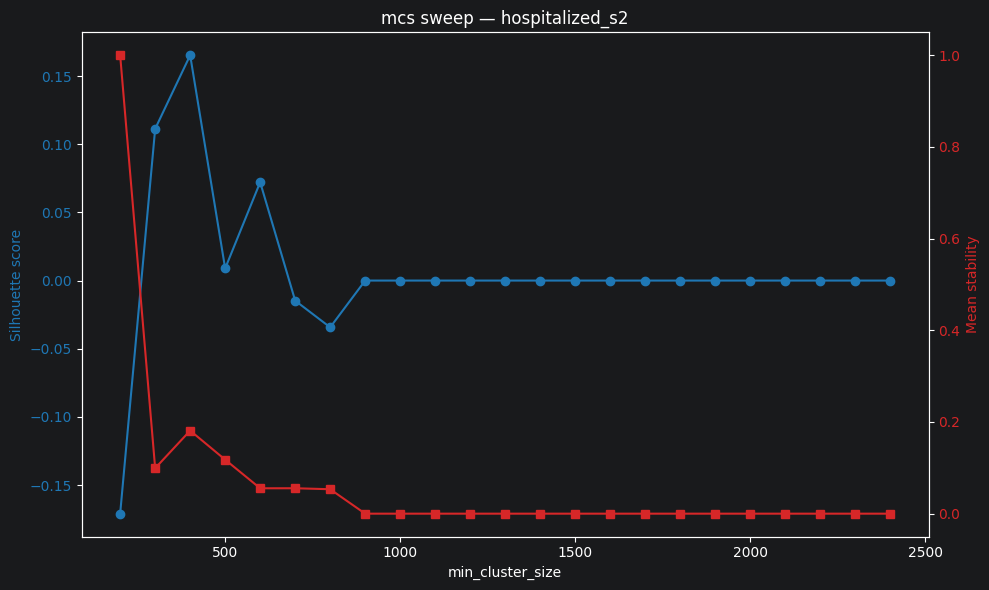

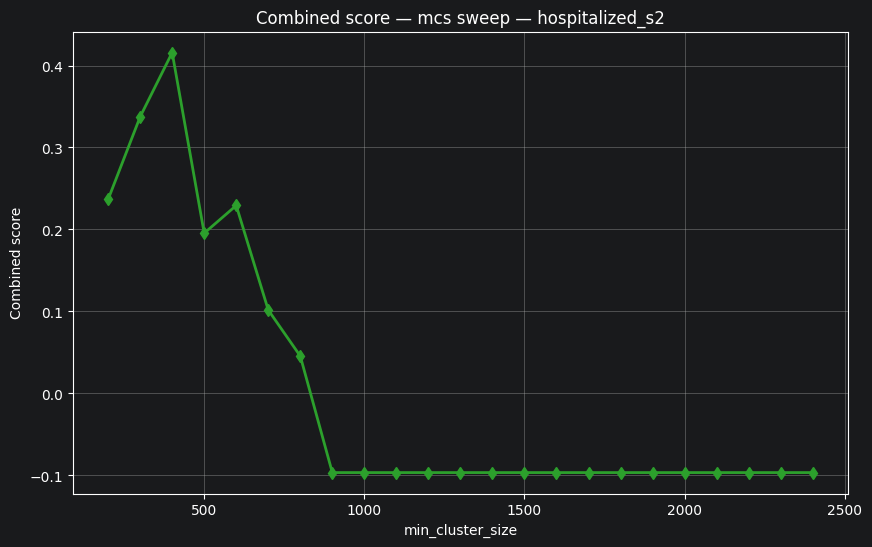

INFO | [hospitalized_s3] binary=42 | cat=9 | quanti=2 | n=3757


 min_cluster_size  n_clusters  silhouette  outlier_rate  stability  combined_score
              200           6   -0.170957      0.211073   1.000000        0.236678
              300           3    0.111276      0.093426   0.099097        0.337487
              400           2    0.165249      0.128560   0.181220        0.415798
              500           3    0.008893      0.179398   0.117746        0.195480
              600           2    0.072141      0.255257   0.055340        0.229250
              700           2   -0.014727      0.335906   0.055433        0.101732
              800           2   -0.034304      0.443439   0.053280        0.045535
              900           0    0.000000      1.000000   0.000000       -0.096604
             1000           0    0.000000      1.000000   0.000000       -0.096604
             1100           0    0.000000      1.000000   0.000000       -0.096604
             1200           0    0.000000      1.000000   0.000000       -0.096604
    

INFO | [hospitalized_s3] Distance matrix: 42.7s
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
INFO | [hospitalized_s3] UMAP embedding shape=(3757, 10) — 16.6s
INFO | [hospitalized_s3] HDBSCAN: 0.6s
INFO | [hospitalized_s3] clusters=0 | noise=3757 (100.0%)
INFO | mcs=  200 | clusters=4 | outlier=66.9% | sil=-0.021
INFO | mcs=  300 | clusters=2 | outlier=58.9% | sil=0.017
INFO | mcs=  400 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs=  500 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs=  600 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs=  700 | clusters=0 | outlier=100.0% | sil=nan
INFO | mcs=  8

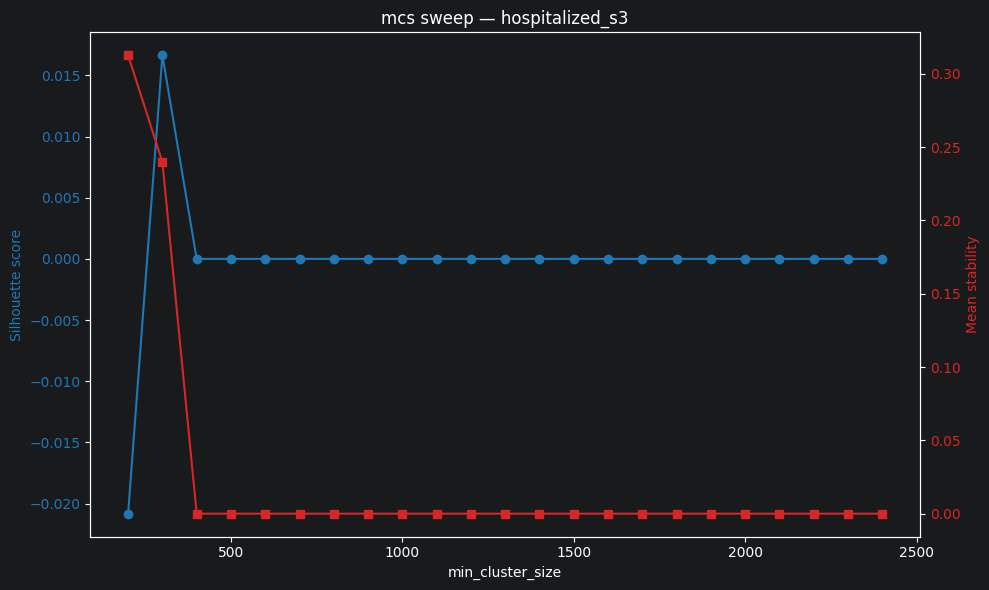

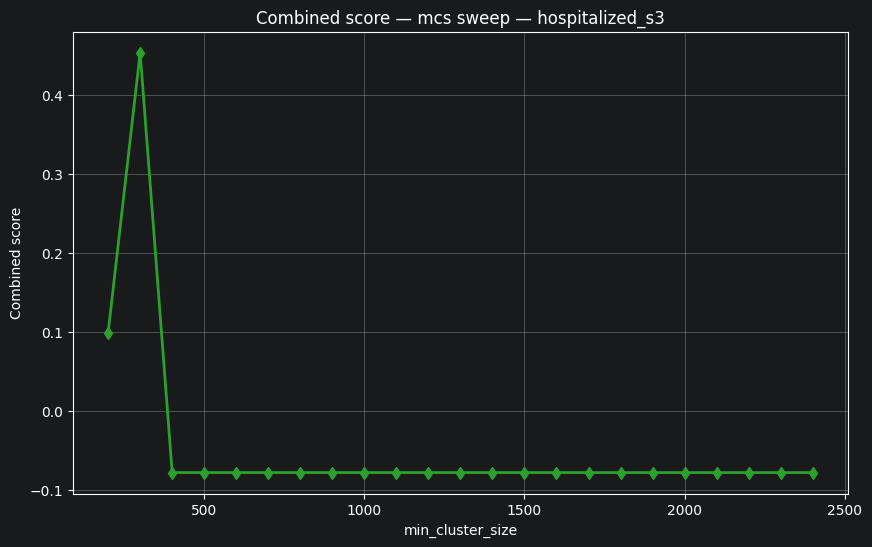

INFO | [discharged_s2] binary=12 | cat=0 | quanti=2 | n=26082


 min_cluster_size  n_clusters  silhouette  outlier_rate  stability  combined_score
              200           4   -0.020826      0.669151   0.312612        0.099255
              300           2    0.016646      0.589300   0.239844        0.453378
              400           0    0.000000      1.000000   0.000000       -0.077686
              500           0    0.000000      1.000000   0.000000       -0.077686
              600           0    0.000000      1.000000   0.000000       -0.077686
              700           0    0.000000      1.000000   0.000000       -0.077686
              800           0    0.000000      1.000000   0.000000       -0.077686
              900           0    0.000000      1.000000   0.000000       -0.077686
             1000           0    0.000000      1.000000   0.000000       -0.077686
             1100           0    0.000000      1.000000   0.000000       -0.077686
             1200           0    0.000000      1.000000   0.000000       -0.077686
    

INFO | [discharged_s2] Distance matrix: 19.4s
INFO | [discharged_s2] HDBSCAN: 71.1s
INFO | [discharged_s2] clusters=6 | noise=5887 (22.6%)
INFO | mcs=  200 | clusters=22 | outlier=4.0% | sil=0.787
INFO | mcs=  300 | clusters=19 | outlier=5.2% | sil=0.747
INFO | mcs=  400 | clusters=16 | outlier=9.2% | sil=0.724
INFO | mcs=  500 | clusters=16 | outlier=8.2% | sil=0.699
INFO | mcs=  600 | clusters=14 | outlier=9.7% | sil=0.654
INFO | mcs=  700 | clusters=12 | outlier=13.7% | sil=0.569
INFO | mcs=  800 | clusters=8 | outlier=13.1% | sil=0.437
INFO | mcs=  900 | clusters=8 | outlier=13.6% | sil=0.436
INFO | mcs= 1000 | clusters=6 | outlier=22.6% | sil=0.354
INFO | mcs= 1100 | clusters=7 | outlier=23.1% | sil=0.354
INFO | mcs= 1200 | clusters=7 | outlier=23.3% | sil=0.354
INFO | mcs= 1300 | clusters=6 | outlier=10.7% | sil=0.384
INFO | mcs= 1400 | clusters=5 | outlier=32.3% | sil=0.376
INFO | mcs= 1500 | clusters=5 | outlier=22.4% | sil=0.310
INFO | mcs= 1600 | clusters=5 | outlier=22.7% | 

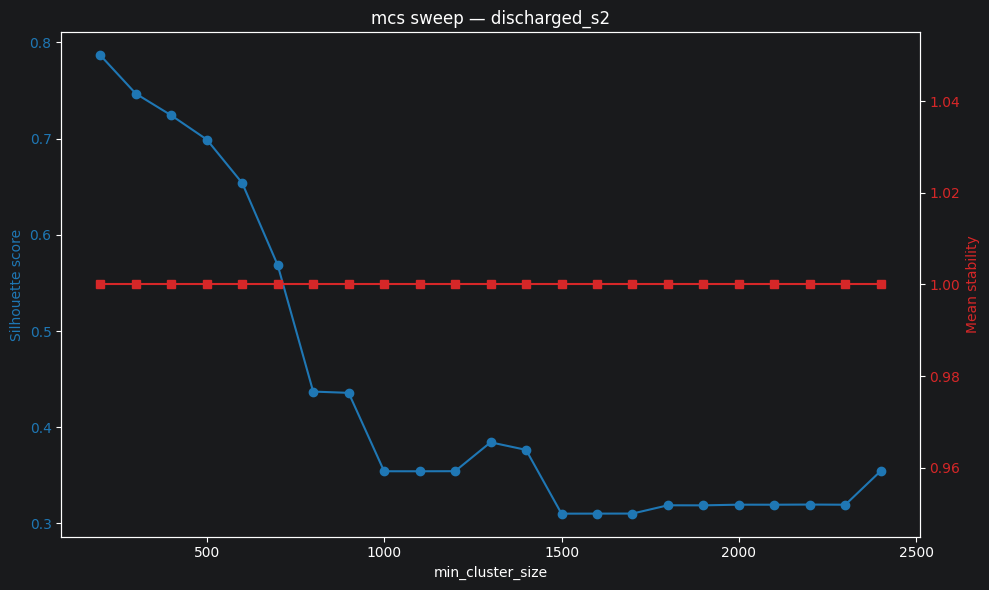

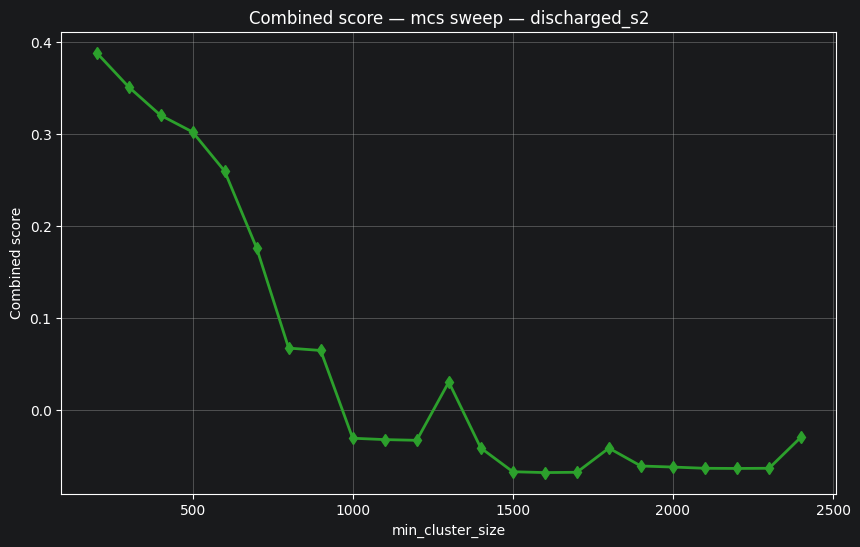

INFO | [discharged_s3] binary=41 | cat=10 | quanti=2 | n=26082


 min_cluster_size  n_clusters  silhouette  outlier_rate  stability  combined_score
              200          22    0.786721      0.040066        1.0        0.387980
              300          19    0.746825      0.052258        1.0        0.350837
              400          16    0.724218      0.092133        1.0        0.319901
              500          16    0.699122      0.082279        1.0        0.301794
              600          14    0.653868      0.097232        1.0        0.259326
              700          12    0.568563      0.136838        1.0        0.175848
              800           8    0.437057      0.131317        1.0        0.067130
              900           8    0.435733      0.136148        1.0        0.064569
             1000           6    0.354221      0.225711        1.0       -0.030713
             1100           7    0.354204      0.230619        1.0       -0.032199
             1200           7    0.354288      0.233456        1.0       -0.032980
    

INFO | [discharged_s3] Distance matrix: 2964.4s
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
INFO | [discharged_s3] UMAP embedding shape=(26082, 10) — 131.0s
INFO | [discharged_s3] HDBSCAN: 4.3s
INFO | [discharged_s3] clusters=4 | noise=13215 (50.7%)
INFO | mcs=  200 | clusters=32 | outlier=14.0% | sil=0.480
INFO | mcs=  300 | clusters=24 | outlier=19.5% | sil=0.404
INFO | mcs=  400 | clusters=16 | outlier=21.3% | sil=0.439
INFO | mcs=  500 | clusters=13 | outlier=27.3% | sil=0.365
INFO | mcs=  600 | clusters=10 | outlier=34.2% | sil=0.280
INFO | mcs=  700 | clusters=7 | outlier=41.0% | sil=0.200
INFO | mcs

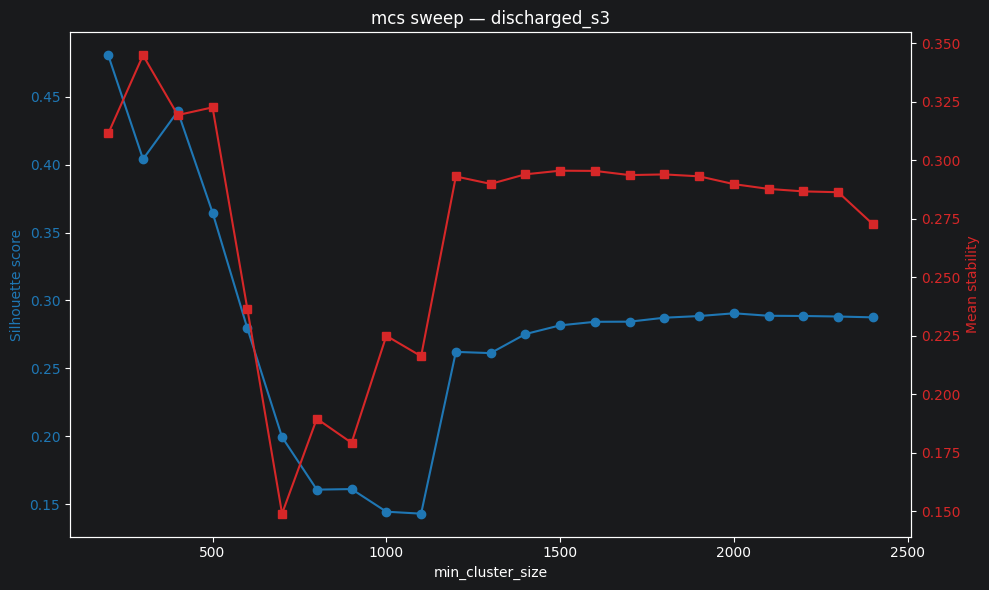

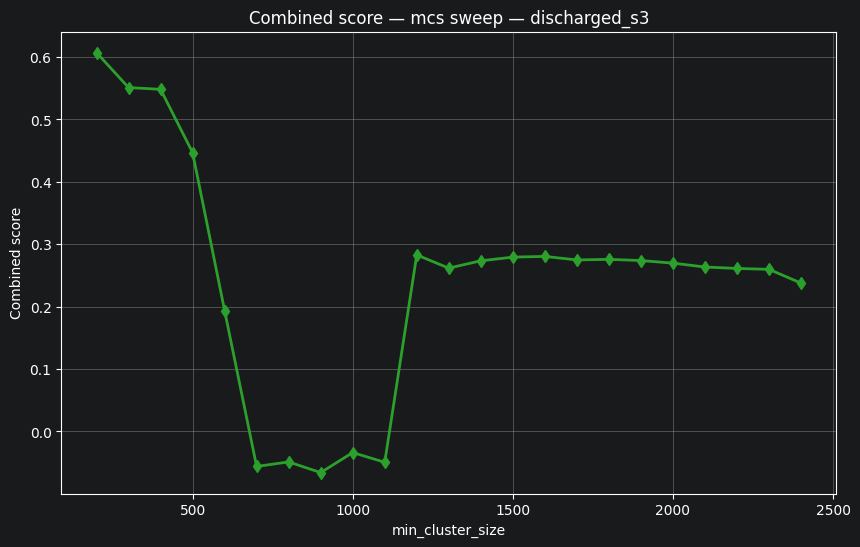

 min_cluster_size  n_clusters  silhouette  outlier_rate  stability  combined_score
              200          32    0.480384      0.139790   0.311347        0.606859
              300          24    0.403972      0.195000   0.344772        0.550853
              400          16    0.439104      0.213059   0.319227        0.547978
              500          13    0.364696      0.273177   0.322511        0.446704
              600          10    0.279641      0.341653   0.236554        0.193582
              700           7    0.199506      0.409823   0.148939       -0.056150
              800           5    0.160876      0.439997   0.189501       -0.048890
              900           5    0.161282      0.445978   0.179204       -0.065979
             1000           4    0.144646      0.506671   0.224922       -0.033885
             1100           4    0.143199      0.508435   0.216207       -0.049481
             1200           2    0.262199      0.263783   0.292991        0.282709
    

In [21]:
# ==============================================================================
# STEP 1: Split dataset + distance matrices + mcs sweep
# ==============================================================================

df = load_and_preprocess(CSV_PATH)

# Split by hospitalization
df_hosp = df[df["hospitalization"] == 1].copy().reset_index(drop=True)
df_disc = df[df["hospitalization"] == 0].copy().reset_index(drop=True)

print(f"Hospitalized  : {len(df_hosp)} patients")
print(f"Discharged    : {len(df_disc)} patients")

stored = {}

for group_name, df_group in [("hospitalized", df_hosp), ("discharged", df_disc)]:

    print(f"\n{'#'*60}\nGROUP: {group_name}\n{'#'*60}")

    # ── Scenario 2 — MinMax, no hospitalization weighting ─────────────────────
    label   = f"{group_name}_s2"
    out_dir = os.path.join(OUTPUT_DIR, group_name, "scenario_2")
    os.makedirs(out_dir, exist_ok=True)

    print(f"\n--- {label} ---")
    df_sub, D, fit_input, labels, clusterer = run_hdbscan(
        df_group,
        scenario_name   = "scenario_2",
        run_label       = label,
        distance_metric = "precomputed",
        scaler          = SCALERS,
        weight_hosp     = 1.0,    # no weighting — already split by hosp
        weight_quanti   = 1.0,
    )
    stored[label] = {"df_sub": df_sub, "D": D, "fit_input": fit_input,
                     "metric": "precomputed", "df_group": df_group}

    df_sweep = run_hdbscan_sweep(fit_input, metric="precomputed")
    df_sweep = compute_combined_score(df_sweep)
    df_sweep.drop(columns=["labels", "probabilities", "cluster_sizes", "clusterer"]) \
            .to_csv(os.path.join(out_dir, "mcs_sweep.csv"), index=False)
    plot_sweep_curves(df_sweep, title=f"mcs sweep — {label}",
                      out_dir=out_dir, filename_prefix=label)

    print(df_sweep[["min_cluster_size", "n_clusters", "silhouette",
                     "outlier_rate", "stability", "combined_score"]].to_string(index=False))

    # ── Scenario 3 — Gower catdown, no hospitalization weighting ──────────────
    label   = f"{group_name}_s3"
    out_dir = os.path.join(OUTPUT_DIR, group_name, "scenario_3")
    os.makedirs(out_dir, exist_ok=True)

    print(f"\n--- {label} ---")
    df_sub, D, fit_input, labels, clusterer = run_hdbscan(
        df_group,
        scenario_name   = "scenario_3",
        run_label       = label,
        distance_metric = "gower",
        gower_weights   = {
            **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
            **{col: WEIGHT_IMAGING_DETAILED  for col in IMAGING_COLS_DETAILED},
        },
    )
    stored[label] = {"df_sub": df_sub, "D": D, "fit_input": fit_input,
                     "metric": "euclidean", "df_group": df_group}

    df_sweep = run_hdbscan_sweep(fit_input, metric="euclidean")
    df_sweep = compute_combined_score(df_sweep)

    df_sweep.drop(columns=["labels", "probabilities", "cluster_sizes", "clusterer"]) \
            .to_csv(os.path.join(out_dir, "mcs_sweep.csv"), index=False)
    plot_sweep_curves(df_sweep, title=f"mcs sweep — {label}",
                      out_dir=out_dir, filename_prefix=label)

    print(df_sweep[["min_cluster_size", "n_clusters", "silhouette",
                     "outlier_rate", "stability", "combined_score"]].to_string(index=False))

print("\n→ Update BEST_MCS in Chunk 1 then run Chunk 4")

---
## CHUNK 4 — STEP 2: min_samples sweep

**⚠️ Before running this chunk:**
1. Analyze the sweep results from Chunk 3
2. Update `BEST_MCS_*` values in Chunk 1 (Configuration)
3. Re-run Chunk 1 to apply the new values

**Goal:** For each chosen `mcs`, find the optimal `min_samples`.

`min_samples` controls how strict the density definition is:
- **Large min_samples** → stricter density → more outliers, more compact clusters
- **Small min_samples** → looser density → fewer outliers, more inclusive clusters
- **min_samples = 1** → no density constraint (reference extreme: no outliers)

**After running:** Choose the min_samples that gives the best balance of outlier rate / cluster coherence. Update `FINAL_PARAMS` in Chunk 1.

In [22]:
# # ==============================================================================
# # STEP 2: min_samples sweep for each chosen mcs
# # ==============================================================================
# # Uses the distance matrices / embeddings computed in Step 1 (stored in `stored`).
# # No need to recompute the distance matrices!
#
# # ──────────────────────────────────────────────────────────────────────────────
# # SCENARIO 2 — MinMax scaler
# # ──────────────────────────────────────────────────────────────────────────────
#
# print("SCENARIO 2 — MinMax scaler")
# print("="*60)
#
# for run_label, best_mcs in [
#     ("s2_noweights", BEST_MCS_S2_NOWEIGHTS),
#     ("s2_hosp3x",    BEST_MCS_S2_HOSP3X),
# ]:
#     label   = f"{run_label}_minmax"
#     out_dir = os.path.join(OUTPUT_DIR, "minmax", run_label, "ms_sweep")
#     s       = stored[label]
#
#     print(f"\n--- {label} | mcs={best_mcs} ---")
#     df_ms = run_min_samples_sweep(
#         fit_input = s["fit_input"],
#         metric    = s["metric"],
#         best_mcs  = best_mcs,
#         run_label = label,
#         out_dir   = out_dir,
#     )
#     print(df_ms[["min_samples", "n_clusters", "outlier_rate", "silhouette", "stability"]].to_string(index=False))
#
#
# # ──────────────────────────────────────────────────────────────────────────────
# # SCENARIO 2 — Standard scaler
# # ──────────────────────────────────────────────────────────────────────────────
#
# print("\nSCENARIO 2 — Standard scaler")
# print("="*60)
#
# for run_label, best_mcs in [
#     ("s2_noweights", BEST_MCS_S2_NOWEIGHTS),
#     ("s2_hosp3x",    BEST_MCS_S2_HOSP3X),
# ]:
#     label   = f"{run_label}_standard"
#     out_dir = os.path.join(OUTPUT_DIR, "standard", run_label, "ms_sweep")
#     s       = stored[label]
#
#     print(f"\n--- {label} | mcs={best_mcs} ---")
#     df_ms = run_min_samples_sweep(
#         fit_input = s["fit_input"],
#         metric    = s["metric"],
#         best_mcs  = best_mcs,
#         run_label = label,
#         out_dir   = out_dir,
#     )
#     print(df_ms[["min_samples", "n_clusters", "outlier_rate", "silhouette", "stability"]].to_string(index=False))
#
#
# # ──────────────────────────────────────────────────────────────────────────────
# # SCENARIO 3 — Gower + UMAP
# # ──────────────────────────────────────────────────────────────────────────────
#
# print("\nSCENARIO 3 — Gower + UMAP")
# print("="*60)
#
# for run_label, best_mcs in [
#     ("s3_noweights",        BEST_MCS_S3_NOWEIGHTS),
#     ("s3_catdown",          BEST_MCS_S3_CATDOWN),
#     ("s3_catdown_hosp5x",   BEST_MCS_S3_HOSP5X),
# ]:
#     out_dir = os.path.join(OUTPUT_DIR, "gower", run_label, "ms_sweep")
#     s       = stored[run_label]
#
#     print(f"\n--- {run_label} | mcs={best_mcs} ---")
#     df_ms = run_min_samples_sweep(
#         fit_input = s["fit_input"],
#         metric    = s["metric"],   # "euclidean" (UMAP embedding)
#         best_mcs  = best_mcs,
#         run_label = run_label,
#         out_dir   = out_dir,
#     )
#     print(df_ms[["min_samples", "n_clusters", "outlier_rate", "silhouette", "stability"]].to_string(index=False))
#
#
# print("\n" + "="*60)
# print("STEP 2 COMPLETE")
# print("="*60)
# print("→ Review the min_samples sweep plots above")
# print("→ Update FINAL_PARAMS in Chunk 1 (Configuration)")
# print("→ Then run Chunk 5 (final run with full visualizations)")

---
## CHUNK 5 — STEP 3: Final run with full visualizations

**⚠️ Before running this chunk:**
1. Update `FINAL_PARAMS` in Chunk 1 with the optimal `(mcs, min_samples)` for each run
2. Re-run Chunk 1 to apply

**What this chunk produces for each run:**
- HDBSCAN native trees (condensed tree, single linkage tree, cluster persistence)
- Cluster profile heatmap + dendrogram
- UMAP 2D/3D projections (interactive HTML for 3D)
- t-SNE 2D/3D projections
- Outlier description (heatmap + bar chart + CSV)

In [23]:
# # ==============================================================================
# # STEP 3: Final run with full visualizations
# # ==============================================================================
#
# for group_name, df_group in [("hospitalized", df_hosp), ("discharged", df_disc)]:
#
#     print(f"\n{'#'*60}\nFINAL RUN — {group_name}\n{'#'*60}")
#
#     # ── Scenario 2 ────────────────────────────────────────────────────────────
#     label        = f"{group_name}_s2"
#     mcs, ms      = FINAL_PARAMS[label]
#     out_dir      = os.path.join(OUTPUT_DIR, group_name,
#                                 "scenario_2", f"final_mcs{mcs}_ms{ms}")
#
#     print(f"\n--- {label} | mcs={mcs}, min_samples={ms} ---")
#     df_sub, D, fit_input, labels, clusterer = run_hdbscan(
#         df_group,
#         scenario_name    = "scenario_2",
#         run_label        = label,
#         distance_metric  = "precomputed",
#         scaler           = SCALERS,
#         weight_hosp      = 1.0,
#         weight_quanti    = 1.0,
#         min_cluster_size = mcs,
#         min_samples      = ms,
#         force_cpu        = len(df_group) < 30_000,
#     )
#     run_full_postprocessing(
#         df_sub=df_sub, D=D, fit_input=fit_input,
#         labels=labels, clusterer=clusterer,
#         run_label=label, out_dir=out_dir, metric="precomputed",
#     )
#
#     # ── Scenario 3 ────────────────────────────────────────────────────────────
#     label        = f"{group_name}_s3"
#     mcs, ms      = FINAL_PARAMS[label]
#     out_dir      = os.path.join(OUTPUT_DIR, group_name,
#                                 "scenario_3", f"final_mcs{mcs}_ms{ms}")
#
#     print(f"\n--- {label} | mcs={mcs}, min_samples={ms} ---")
#     df_sub, D, fit_input, labels, clusterer = run_hdbscan(
#         df_group,
#         scenario_name    = "scenario_3",
#         run_label        = label,
#         distance_metric  = "gower",
#         gower_weights    = {
#             **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
#             **{col: WEIGHT_IMAGING_DETAILED  for col in IMAGING_COLS_DETAILED},
#         },
#         min_cluster_size = mcs,
#         min_samples      = ms,
#     )
#     run_full_postprocessing(
#         df_sub=df_sub, D=D, fit_input=fit_input,
#         labels=labels, clusterer=clusterer,
#         run_label=label, out_dir=out_dir, metric="euclidean",
#     )
#
# print("\nPIPELINE COMPLETE ✅")

# A CORRIGER AVEC VRAI CHIFFRES




## Analyse comparative des clusterings splitté (hospitalisés vs dischargés)

### Résultats du sweep

**Dischargés (n ≈ 21 000)**
- Stabilité = 1.0 pour tous les mcs
- Silhouette élevé (0.82 à mcs=200, 0.75 à mcs=500)
- Taux d'outliers très bas (1-5%)
- → Structure claire, stable et reproductible
- → mcs optimal retenu : **500 → 15 clusters**

**Hospitalisés (n ≈ 9 000)**
- Stabilité = 1.0 uniquement à mcs=200 (12 clusters)
- Silhouette bas (0.36) et chute rapide
- À partir de mcs=1500 → 0 clusters, tout en bruit
- → Structure très faible et instable

---

### Interprétation clinique

Les patients dischargés présentent des **profils de consommation de soins homogènes et distincts** — certains types de bilans sont reproductibles et prévisibles.

Les patients hospitalisés sont au contraire **très hétérogènes** : la décision d'hospitalisation dépend du diagnostic, de la gravité et du contexte social, facteurs qui ne sont pas capturés par les variables de consommation de soins seules. Ce n'est pas un manque de données — c'est une réalité clinique.

---

### Implications pour la prédiction au triage

- ✅ Il est possible de prédire le **profil de consommation de soins** d'un patient à l'arrivée
- ❌ Il n'est **pas possible** de prédire l'hospitalisation uniquement depuis les patterns de consommation, car les hospitalisés ne forment pas de clusters stables

---

### Décision méthodologique

Le clustering splitté est **abandonné** au profit du **clustering global (s2_noweights)** pour trois raisons :

1. Les hospitalisés ne forment pas de clusters stables → résultats peu fiables
2. L'objectif est la prédiction au triage → l'issue (hospitalisation) n'est pas encore connue à ce stade
3. Le clustering global est plus riche : les hospitalisés dispersés dans 4-5 clusters avec des taux de 25-60% constituent une information clinique en soi

La description des clusters globaux permettra d'identifier quels profils de consommation sont associés à un risque d'hospitalisation élevé, sans imposer artificiellement une séparation.

---

### Conclusion

> *"Les patients hospitalisés ne forment pas de profils de consommation de soins homogènes, suggérant que la décision d'hospitalisation dépend de facteurs cliniques au-delà de la consommation de soins mesurée aux urgences."*